# Daily Trace Gases repository

This is a Colab demo for the codebase at: https://github.com/emit-sds/daily-trace-gases/

Please refer to the main repository for any updates.

## 1.) Prepare libraries and data

In [ ]:
# Clone the codebase
!git clone https://github.com/emit-sds/daily-trace-gases.git

In [ ]:
%cd /content/daily-trace-gases

/content/daily-trace-gases


In [ ]:
# Download machine learning model weights
!hf download previtus/JPL_TRACE_GASES_MODELS --local-dir models/JPL_TRACE_GASES_MODELS

In [ ]:
# Install required libraries
# (note: that you might need to make adjustments to the versions as the main Google Colab environment changes ...)
!pip install -r requirements.txt
# extra for local plots:
!pip install matplotlib-scalebar

In [ ]:
# Now you will need to login to the NASA's portal https://www.earthdata.nasa.gov/data/tools/earthdata-search
import earthaccess
auth = earthaccess.login(persist=True)

## 2.) Use our system for detection of trace gases

In [ ]:
from detect_trace_gas import detect_trace_gas

# Choose one of these example scenes:
tile_ID = "EMIT_L1B_RAD_001_20260102T143123_2600209_005"
gas = "ch4"
# tile_ID = "EMIT_L1B_RAD_001_20250418T090845_2510806_029"
# gas = "no2"
# tile_ID = "EMIT_L1B_RAD_001_20231223T123029_2335708_008"
# gas = "nh3"
# tile_ID = "EMIT_L1B_RAD_001_20230623T031429_2317402_015"
# gas = "co"
## Note: the code might crash RAM on the basic instance of Google Colab as it provides limited RAM

results_folder = "results"
raws_folder = "intermediates_folder"

detect_trace_gas(gas, tile_ID, results_folder, raws_folder)

Running detection of ch4 in EMIT tile: EMIT_L1B_RAD_001_20260102T143123_2600209_005
----------------------------------------
Step 1: getting data, computing WMF, RGB
Already dowloaded previously, skipping!
----------------------------------------
Step 2: model prediction
Loading and formatting model inputs
Loading model weights and predicting
Loading model from /content/daily-trace-gases/models/JPL_TRACE_GASES_MODELS/ch4_UNET_RGB_WMF/UNET_RGB_WMF_R1_best_vf1_ep13.pt
Weights loaded!
Loading model from /content/daily-trace-gases/models/JPL_TRACE_GASES_MODELS/ch4_UNET_RGB_WMF/UNET_RGB_WMF_R2_best_vf1_ep30.pt
Weights loaded!
Loading model from /content/daily-trace-gases/models/JPL_TRACE_GASES_MODELS/ch4_UNET_RGB_WMF/UNET_RGB_WMF_R3_best_vf1_ep30.pt
Weights loaded!
Loading model from /content/daily-trace-gases/models/JPL_TRACE_GASES_MODELS/ch4_UNET_RGB_WMF/UNET_RGB_WMF_R4_best_vf1_ep50.pt
Weights loaded!
Loading model from /content/daily-trace-gases/models/JPL_TRACE_GASES_MODELS/ch4_UNET_RG

Saved prediction to results/EMIT_L1B_RAD_001_20260102T143123_2600209_005/prediction_ensemble.tif !
Saved vectors to results/EMIT_L1B_RAD_001_20260102T143123_2600209_005/prediction_ensemble.geojson !
----------------------------------------
Step 3: scoring predictions
loading vector from results/EMIT_L1B_RAD_001_20260102T143123_2600209_005/prediction_ensemble.geojson
Loaded data for [EMIT_L1B_RAD_001_20260102T143123_2600209_005]: L1A: (2033, 2170, 285) CMF: (2033, 2170) cloud mask: (2033, 2170) and 11  polygons!
Scoring vectors
Polygon #0 (100px)
Polygon #1 (374px)
Polygon #2 (51px)
Polygon #3 (266px)
Polygon #4 (7942px)
Polygon #5 (775px)
Polygon #6 (34px)
Polygon #7 (354px)
Polygon #8 (1374px)
Polygon #9 (11px)
Polygon #10 (28px)
Saving scored vectors
Polygons saved as FeatureCollection to results/EMIT_L1B_RAD_001_20260102T143123_2600209_005/prediction_ensemble_scored.geojson


## 3.) Inspect results

In [ ]:
# The results are saved into "results_folder".
# - for ch4 we save ch4-wmf.tif, rgb.tif and the scored predictions in prediction_ensemble_scored.geojson
# - for other trace gases we save files named by the targeted gas,
#     for example producing co-cmf.tif and predictions co-prediction_scored.geojson

In [ ]:
!ls results/EMIT_L1B_RAD_001_20260102T143123_2600209_005/

ch4-wmf.tif		     prediction_ensemble_scored.geojson  rgb.tif
prediction_ensemble.geojson  prediction_ensemble.tif


<Axes: >

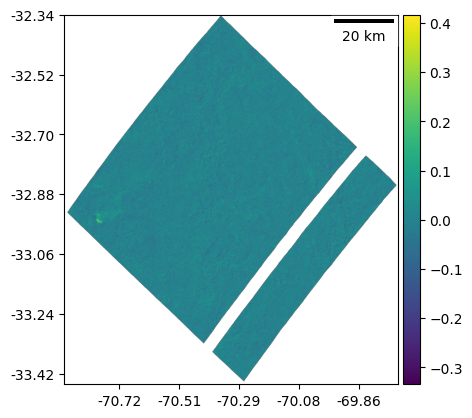

In [ ]:
from georeader.rasterio_reader import RasterioReader
from georeader.plot import show

# change depending on the used example ...
mf_geo = RasterioReader("results/EMIT_L1B_RAD_001_20260102T143123_2600209_005/ch4-wmf.tif")
show(mf_geo, mask=True, add_scalebar=True, add_colorbar_next_to = True)

<Axes: >

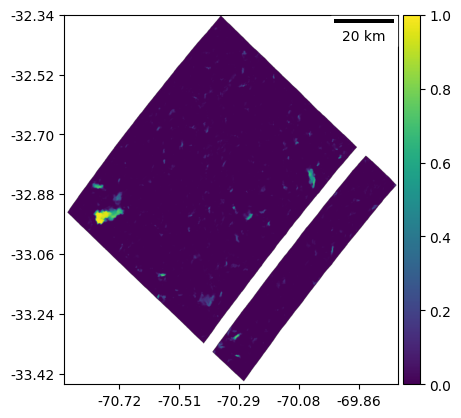

In [ ]:
pred_geo = RasterioReader("results/EMIT_L1B_RAD_001_20260102T143123_2600209_005/prediction_ensemble.tif")
show(pred_geo, mask=True, add_scalebar=True, add_colorbar_next_to = True, vmin=0.0, vmax=1.0)

<Axes: >

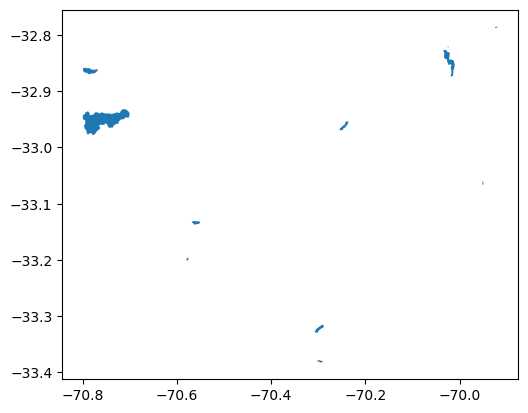

In [ ]:
import geopandas as gpd
gdf = gpd.read_file("results/EMIT_L1B_RAD_001_20260102T143123_2600209_005/prediction_ensemble_scored.geojson")
gdf.plot()

In [ ]:
# sorted by D_norm
gdf_sorted = gdf.sort_values(by='D_norm', ascending=True)
gdf_sorted

,confidence,D_norm,alpha_con_len,number_of_pixels,geometry
4,0.995070,0.154040,3346.592716,7942,"POLYGON ((-70.70044 -32.93849, -70.70054 -32.9..."
7,0.627741,0.590523,1647.017965,354,"POLYGON ((-70.24193 -32.96283, -70.24194 -32.9..."
2,0.542004,0.764054,861.733102,51,"POLYGON ((-70.57677 -33.20094, -70.5787 -33.20..."
9,0.503078,0.794656,1647.858752,11,"POLYGON ((-70.0233 -32.82032, -70.02268 -32.82..."
5,0.760866,0.800337,204.493452,775,"POLYGON ((-70.78296 -32.86104, -70.77975 -32.8..."
1,0.779504,0.859726,404.144391,374,"POLYGON ((-70.28887 -33.32006, -70.29535 -33.3..."
8,0.724814,0.874518,368.680609,1374,"POLYGON ((-70.02278 -32.8306, -70.02087 -32.83..."
10,0.522236,0.980781,273.266574,28,"POLYGON ((-69.92424 -32.78591, -69.91974 -32.7..."
3,0.773121,0.987281,195.545979,266,"POLYGON ((-70.55439 -33.13629, -70.55953 -33.1..."
6,0.548148,0.999995,0.017164,34,"POLYGON ((-69.95152 -33.06063, -69.9496 -33.06..."
